# Estrategia 2: YOLOv8-seg
## Segmentación por Instancias (T1-L5)

**Baseline directo:** Antecedente [16] Dice vértebra 0.74, columna 0.91, 52 MB.

## 0. Setup

In [1]:
%matplotlib inline


import sys
sys.path.insert(0, '/home/becavas/data/repos/spine_seg')

import os, torch, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
print('Setup OK')

Setup OK


## 1. Hiperparámetros

In [2]:
# Imprimir TODOS los hiperparámetros del experimento
from configs.config import *
import torch

print("=" * 70)
print("CONFIGURACIÓN DEL EXPERIMENTO")
print("=" * 70)
print(f"\n📁 DATASET:")
print(f"  Root: {DATASET_ROOT}")
print(f"  Imágenes excluidas: {IMAGES_TO_EXCLUDE}")
print(f"  Clases: {NUM_CLASSES} (17 vértebras T1-L5 + fondo)")
print(f"  Vértebras: {ANATOMICAL_VERTEBRAE}")
print(f"  Clases excluidas: {len(CLASSES_TO_EXCLUDE)} (cervicales + entidades)")
print(f"\n📐 SPLIT:")
print(f"  Train/Val/Test: {TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO}")
print(f"  Seed: {RANDOM_SEED}")
print(f"\n🔧 PREPROCESAMIENTO:")
print(f"  CLAHE: clip={CLAHE_CLIP_LIMIT}, grid={CLAHE_TILE_GRID}")
print(f"  Normalización: mean={PIXEL_MEAN}, std={PIXEL_STD}")
print(f"\n🎲 AUGMENTATION:")
print(f"  Rotación: ±{AUG_ROTATION_LIMIT}°")
print(f"  Shift: ±{AUG_SHIFT_LIMIT}")
print(f"  Scale: {AUG_SCALE_LIMIT}")
print(f"  Brightness: ±{AUG_BRIGHTNESS_LIMIT}, Contrast: ±{AUG_CONTRAST_LIMIT}")
print(f"  Random crop: {AUG_CROP_MIN*100:.0f}-{AUG_CROP_MAX*100:.0f}% (prob={AUG_CROP_PROB})")
print(f"\n⚙️ ENTRENAMIENTO:")
print(f"  Épocas: {MAX_EPOCHS}, Early stopping: {EARLY_STOPPING_PATIENCE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  LR: {LEARNING_RATE}, Weight decay: {WEIGHT_DECAY}")
print(f"  Warmup: {WARMUP_EPOCHS} épocas")
print(f"  AMP: {USE_AMP}")
print(f"\n⚖️ PÉRDIDA:")
print(f"  Dice weight: {DICE_WEIGHT}, CE weight: {CE_WEIGHT}")
print(f"  Boundary loss weight: {BOUNDARY_LOSS_WEIGHT}")
print(f"  Medianas de área (top-3): { {k: v for k, v in sorted(AREA_MEDIANS.items(), key=lambda x: -x[1])[:3]} }")
print(f"  Medianas de área (bottom-3): { {k: v for k, v in sorted(AREA_MEDIANS.items(), key=lambda x: x[1])[:3]} }")
print(f"\n🖥️ HARDWARE:")
device = 'cuda' if torch.cuda.is_available() else ('mps' if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available() else 'cpu')
print(f"  Device: {device}")
if device == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name()}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"\n📂 OUTPUT:")
print(f"  Run: {CURRENT_RUN_DIR}")


print(f'\n🏗️ MODELO:')
print(f'  Arquitectura: YOLOv8-seg')
print(f'  Modelo: {YOLO_MODEL_SIZE}')
print(f'  Input size: {IMG_SIZES["yolo_medium"]}')
print(f'  Freeze layers: {YOLO_FREEZE_LAYERS}')
print(f'  Confidence threshold: {YOLO_CONFIDENCE_THRESHOLD}')

CONFIGURACIÓN DEL EXPERIMENTO

📁 DATASET:
  Root: /home/becavas/data/repos/spine_seg/data
  Imágenes excluidas: ['S_107.jpg']
  Clases: 18 (17 vértebras T1-L5 + fondo)
  Vértebras: ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'L1', 'L2', 'L3', 'L4', 'L5']
  Clases excluidas: 18 (cervicales + entidades)

📐 SPLIT:
  Train/Val/Test: 0.8/0.1/0.1
  Seed: 42

🔧 PREPROCESAMIENTO:
  CLAHE: clip=2.0, grid=(8, 8)
  Normalización: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]

🎲 AUGMENTATION:
  Rotación: ±10°
  Shift: ±0.05
  Scale: (0.9, 1.1)
  Brightness: ±0.1, Contrast: ±0.15
  Random crop: 10-30% (prob=0.3)

⚙️ ENTRENAMIENTO:
  Épocas: 300, Early stopping: 50
  Batch size: 16
  LR: 0.0001, Weight decay: 0.01
  Warmup: 5 épocas
  AMP: True

⚖️ PÉRDIDA:
  Dice weight: 0.5, CE weight: 0.5
  Boundary loss weight: 0.1
  Medianas de área (top-3): {'L4': 3389, 'L3': 3256, 'L2': 3234}
  Medianas de área (bottom-3): {'T1': 1073, 'T4': 1542, 'T2': 1688}

🖥️ HARDWA

## 2. Carga de datos y split

In [3]:
# Carga de datos y split (IDÉNTICO para las 3 estrategias)
from shared.data_loader import (
    load_dataset_index, build_label_mapping,
    load_cobb_metrics, stratified_split
)

df_index, original_id_to_name = load_dataset_index()
label_mapping = build_label_mapping(original_id_to_name)
df_train, df_val, df_test = stratified_split(df_index)
df_cobb = load_cobb_metrics()

# Verificación rápida
print(f"\n📊 Verificación de clases en máscara de ejemplo:")
import cv2, numpy as np
from shared.data_loader import get_mask_multiclass_path
sample_row = df_train.iloc[0]
mask_path = get_mask_multiclass_path(sample_row)
mask_raw = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
print(f"  Imagen: {sample_row['image']}")
print(f"  Máscara dtype: {mask_raw.dtype}, shape: {mask_raw.shape}")
print(f"  Valores únicos raw: {np.unique(mask_raw).tolist()}")
print(f"  Valores después de remapeo: {sorted(set(label_mapping.get(v, 0) for v in np.unique(mask_raw)))}")


{'binary': {'0': 'background', '255': 'spine'}, 'multiclass_id_png': {'0': 'background', '1': 'C7', '2': 'C6', '3': 'C5', '4': 'C4', '5': 'C3', '6': 'T1', '7': 'T2', '8': 'T3', '9': 'T4', '10': 'T5', '11': 'T6', '12': 'T7', '13': 'T8', '14': 'T9', '15': 'T10', '16': 'T11', '17': 'T12', '18': 'L1', '19': 'L2', '20': 'L3', '21': 'L4', '22': 'L5', '23': 'Entity 10', '24': 'Entity 12', '25': 'Entity 13', '26': 'Entity 14', '27': 'Entity 16', '28': 'Entity 17', '29': 'Entity 18', '30': 'Entity 21', '31': 'Entity 3', '32': 'Entity 6', '33': 'Entity 8', '34': '10', '35': '2'}, 'multiclass_gray_jpg': {'0': 0, '1': 7, '2': 15, '3': 22, '4': 29, '5': 36, '6': 44, '7': 51, '8': 58, '9': 66, '10': 73, '11': 80, '12': 87, '13': 95, '14': 102, '15': 109, '16': 117, '17': 124, '18': 131, '19': 138, '20': 146, '21': 153, '22': 160, '23': 168, '24': 175, '25': 182, '26': 189, '27': 197, '28': 204, '29': 211, '30': 219, '31': 226, '32': 233, '33': 240, '34': 248, '35': 255}, 'multiclass_color_rgb': {'0'

## 3. Convertir a formato YOLO

In [4]:
from models.yolo_utils import convert_dataset_to_yolo_format

yaml_path = convert_dataset_to_yolo_format(
    df_train, df_val, df_test, label_mapping, output_dir='yolo_dataset'
)

# Verificar conversión
sample_label = list(Path('yolo_dataset/labels/train').glob('*.txt'))[0]
with open(sample_label) as f:
    lines = f.readlines()
print(f"\nEjemplo: {sample_label.name}")
print(f"  Instancias: {len(lines)}")
print(f"  Primera línea: {lines[0][:80]}...")
print(f"\n  Clases encontradas: {sorted(set(int(l.split()[0]) for l in lines))}") 

  Convirtiendo train: 199 imágenes...
  Convirtiendo val: 25 imágenes...
  Convirtiendo test: 25 imágenes...

Conversión completada:
  Train: 199 imágenes
  Val: 25 imágenes
  Test: 25 imágenes
  Skipped: 0 imágenes
  Clases: 17
  YAML: yolo_dataset/dataset.yaml

Ejemplo: S_43.txt
  Instancias: 12
  Primera línea: 0 0.334802 0.246020 0.334802 0.248915 0.325991 0.253256 0.325991 0.256151 0.3171...

  Clases encontradas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


## 4. Entrenar YOLOv8-seg

In [5]:
from models.yolo_utils import train_yolo
from pathlib  import   Path
yaml_path= str(Path('yolo_dataset/dataset.yaml').resolve())
model_yolo, results = train_yolo(
    yaml_path=yaml_path,
    model_size=YOLO_MODEL_SIZE,
    imgsz=IMG_SIZES['yolo_medium'],
    epochs=MAX_EPOCHS,
    batch=BATCH_SIZE,
    freeze=YOLO_FREEZE_LAYERS,
    project=str(CURRENT_RUN_DIR),
    name='yolo_seg'
)

# Métricas nativas YOLO
print("\n=== Métricas nativas YOLOv8 ===")
for k, v in results.results_dict.items():
    if 'mAP' in k or 'precision' in k or 'recall' in k:
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Entrenando YOLOv8-seg:
  Modelo: yolov8m-seg.pt
  Imagen: 1024px
  Épocas: 300
  Batch: 16
  Freeze: 0 capas
New https://pypi.org/project/ultralytics/8.4.48 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5090, 32101MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/becavas/data/repos/spine_seg/notebooks/yolo_dataset/dataset.yaml, degrees=3.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.03, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_wi

/home/becavas/miniconda3/envs/spine/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1742.1±705.5 MB/s, size: 54.4 KB)
val: Scanning /home/becavas/data/repos/spine_seg/notebooks/yolo_dataset/labels/val.cache... 25 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 25/25 3.9Mit/s 0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.0005' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000476, momentum=0.9) with parameter groups 86 weight(decay=0.0), 97 weight(decay=0.0005), 96 bias(decay=0.0)
Plotting labels to /home/becavas/data/repos/spine_seg/notebooks/outputs/runs/20260509_232831/yolo_seg/labels.jpg... 
Image sizes 1024 train, 1024 val
Using 2 dataloader workers
Logging results to /home/becavas/data/repos/spine_seg/notebooks/outputs/runs/20260509_232831/yolo_seg
Starting training for 300 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
: 0% ──────────── 0/13  0.8s


RuntimeError: CUDA error: CUBLAS_STATUS_ALLOC_FAILED when calling `cublasCreate(handle)`

In [ ]:
#import sys
#import importlib
#if 'models.yolo_utils' in sys.modules:
#    importlib.reload(sys.modules['models.yolo_utils'])

## 5. Evaluación con métricas compartidas (Dice, IoU)

In [ ]:
from ultralytics import YOLO
from models.yolo_utils import evaluate_yolo_with_shared_metrics

best_path = str(CURRENT_RUN_DIR / 'yolo_seg' / 'weights' / 'best.pt')
model_best = YOLO(best_path)

test_metrics = evaluate_yolo_with_shared_metrics(
    model_best, 'yolo_dataset/images/test', label_mapping, YOLO_CONFIDENCE_THRESHOLD
)
summary = test_metrics.compute_summary()
test_metrics.print_summary(summary)
test_metrics.add_severity_analysis(summary, df_cobb)

# Tabla detallada
print("\n" + "=" * 70)
print("TABLA DETALLADA POR CLASE")
print("=" * 70)
df_class = summary['per_class']
print(f"{'Clase':<12} {'Dice':>8} {'±Std':>8} {'IoU':>8} {'N imgs':>8}")
print("-" * 46)
for _, row in df_class.iterrows():
    if row['class_id'] == 0: continue
    print(f"{row['vertebra']:<12} {row['dice_mean']:>8.4f} {row['dice_std']:>8.4f} "
          f"{row['iou_mean']:>8.4f} {row['n_images']:>8.0f}")

Evaluando 25 imágenes de test con métricas compartidas...
RESUMEN DE MÉTRICAS

📊 GLOBAL (sin fondo):
   Dice por vértebra: 0.4251 ± 0.0649
   IoU por vértebra:  0.3784 ± 0.0602
   Dice columna:      0.4232

🦴 POR CLASE:
     T1: Dice=0.5141±0.3777  IoU=0.4312  (n=25)
     T2: Dice=0.4456±0.4332  IoU=0.3951  (n=25)
     T3: Dice=0.3590±0.4094  IoU=0.3084  (n=25)
     T4: Dice=0.4372±0.4143  IoU=0.3766  (n=25)
     T5: Dice=0.3869±0.4258  IoU=0.3408  (n=25)
     T6: Dice=0.3892±0.4349  IoU=0.3490  (n=25)
     T7: Dice=0.4031±0.4224  IoU=0.3534  (n=25)
     T8: Dice=0.4036±0.4245  IoU=0.3543  (n=25)
     T9: Dice=0.4253±0.4490  IoU=0.3884  (n=25)
    T10: Dice=0.4746±0.4354  IoU=0.4252  (n=25)
    T11: Dice=0.5308±0.4374  IoU=0.4819  (n=25)
    T12: Dice=0.3797±0.4361  IoU=0.3415  (n=25)
     L1: Dice=0.3741±0.4375  IoU=0.3378  (n=14)
     L2: Dice=0.3791±0.4489  IoU=0.3482  (n=12)
     L3: Dice=0.3888±0.4493  IoU=0.3563  (n=14)
     L4: Dice=0.5806±0.4398  IoU=0.5350  (n=11)
     L5: Dic

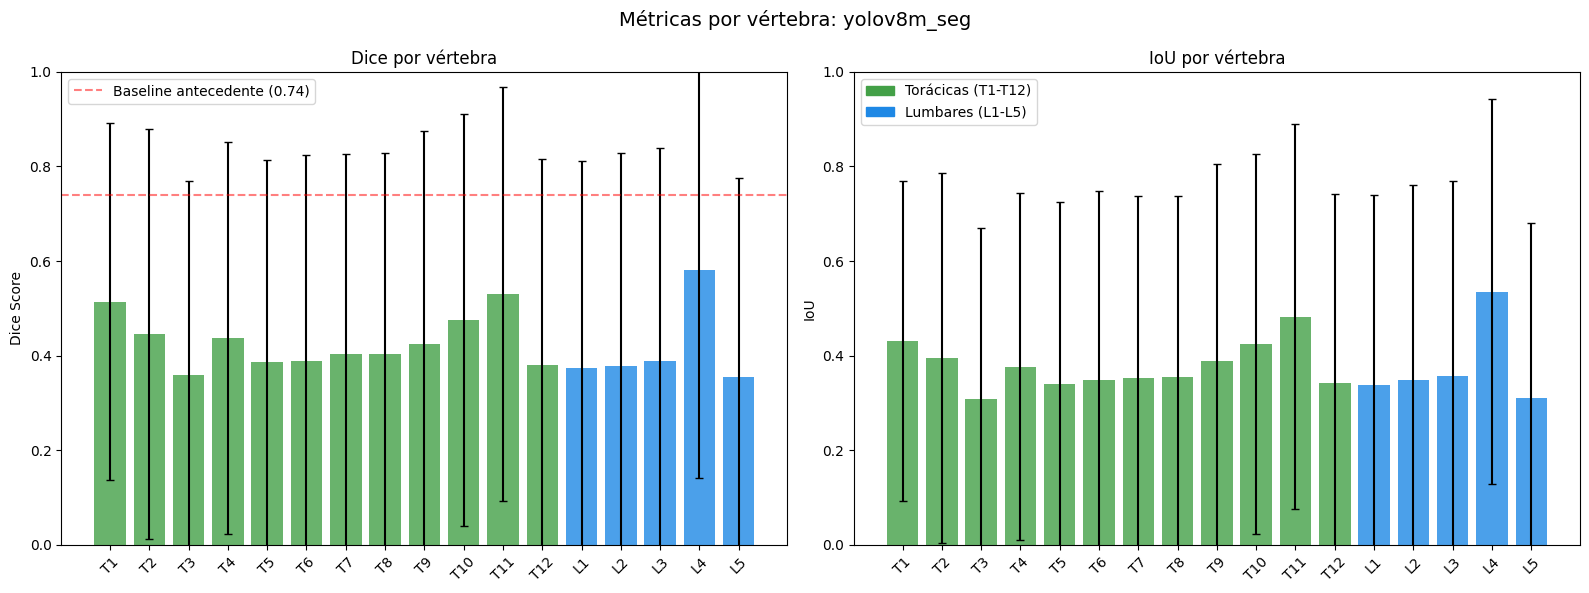

In [ ]:
%matplotlib inline
from shared.visualization import plot_per_class_metrics
plot_per_class_metrics(summary, experiment_name='yolov8m_seg')

## 6. Visualización de predicciones

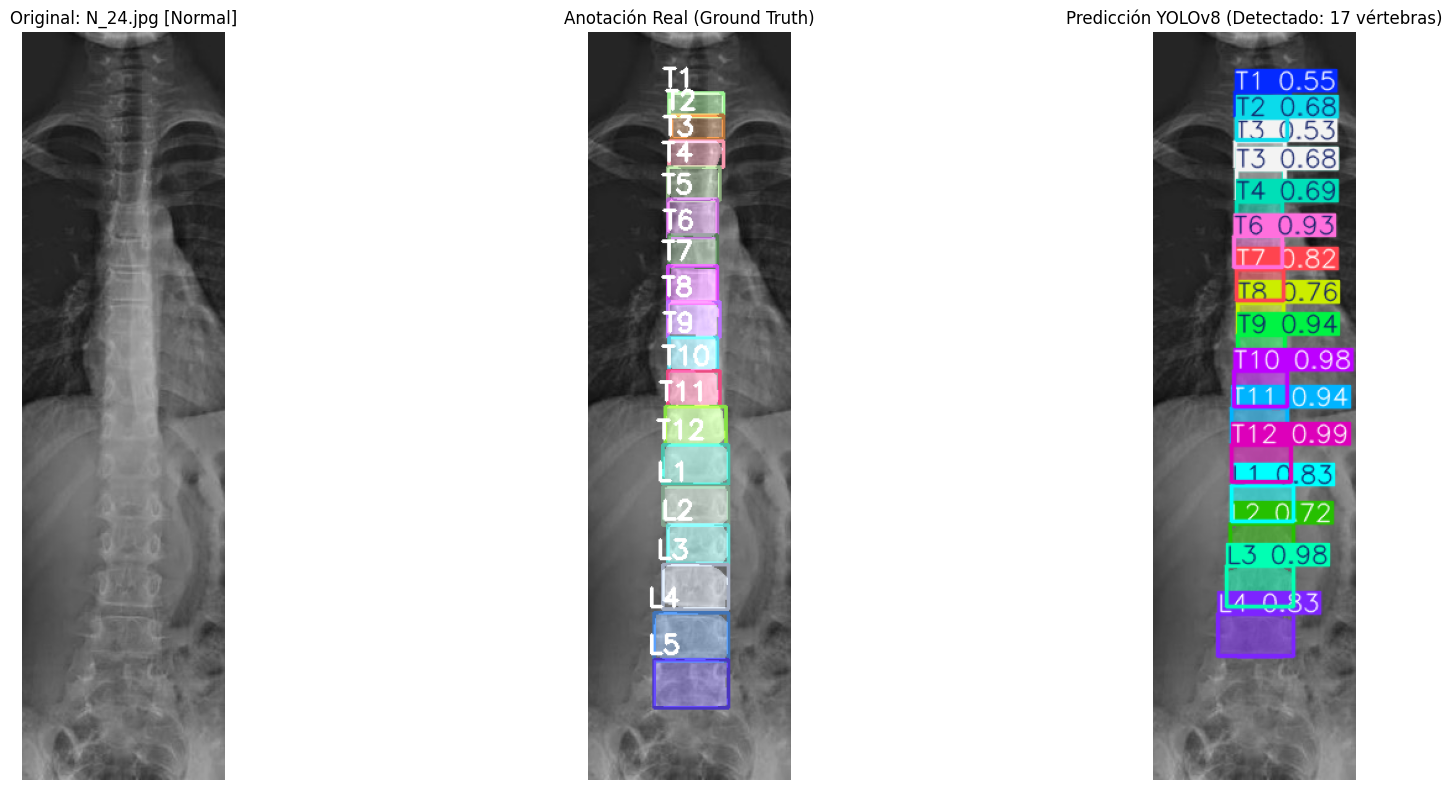

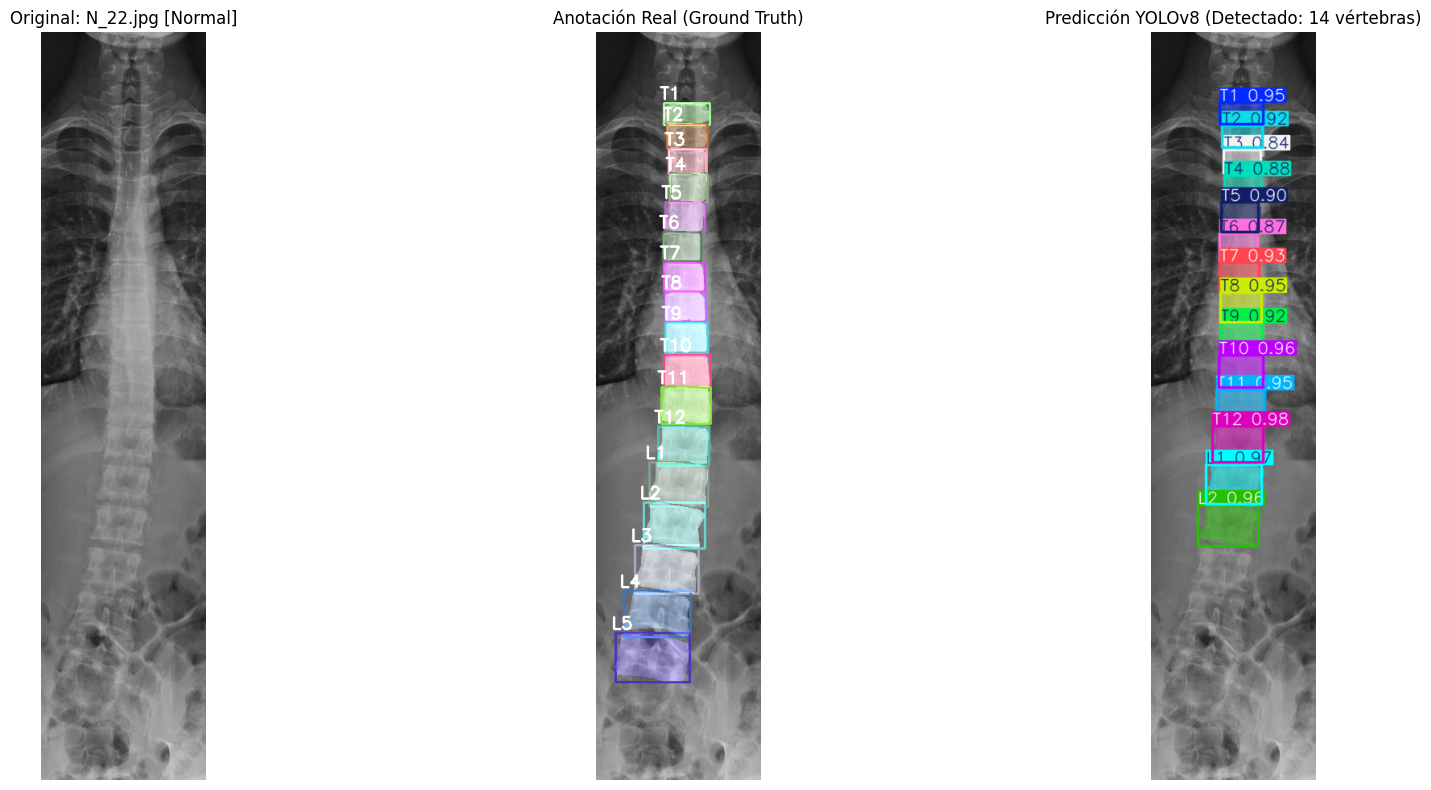

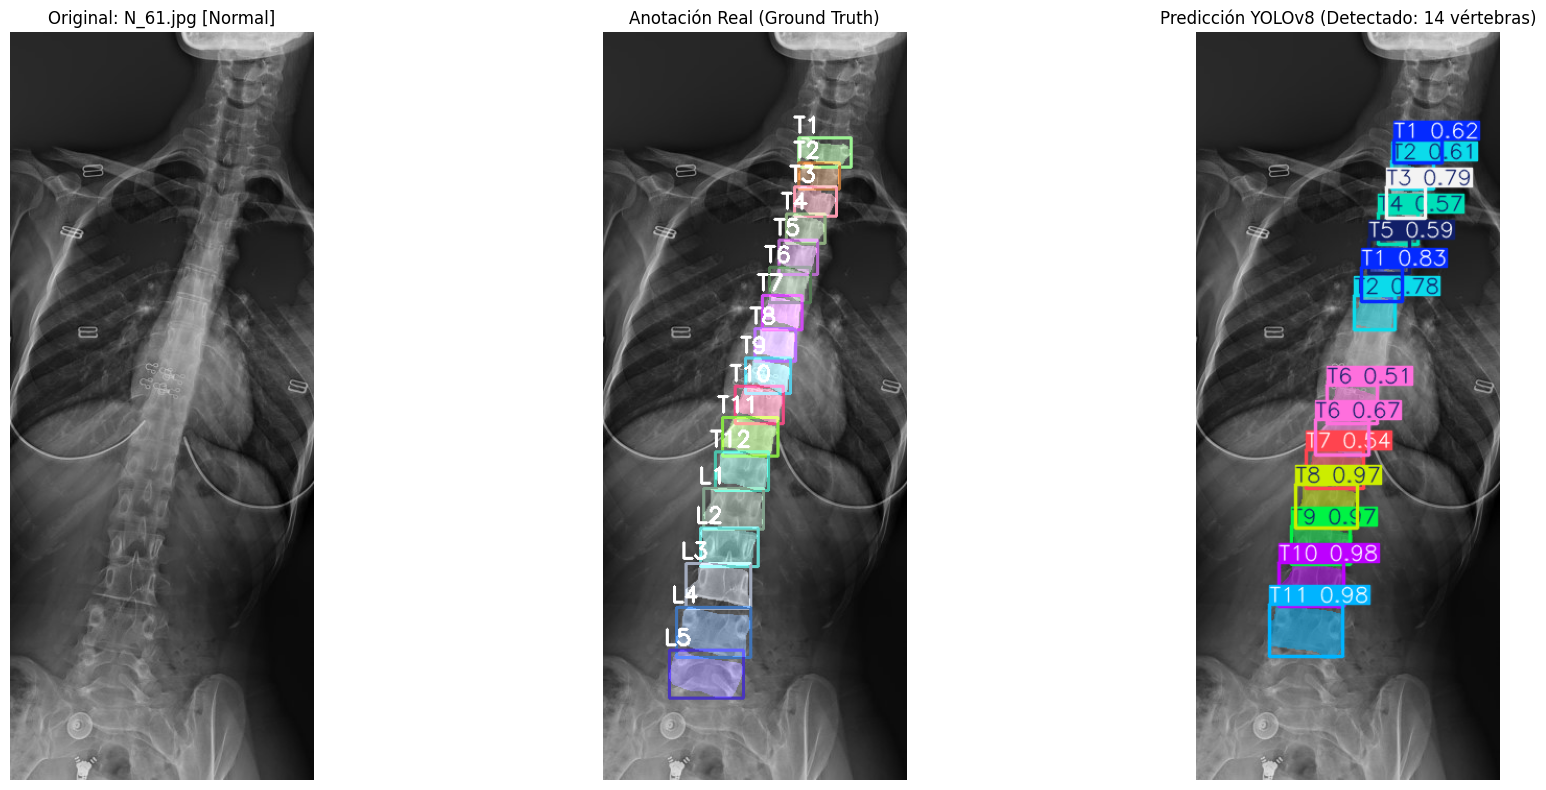

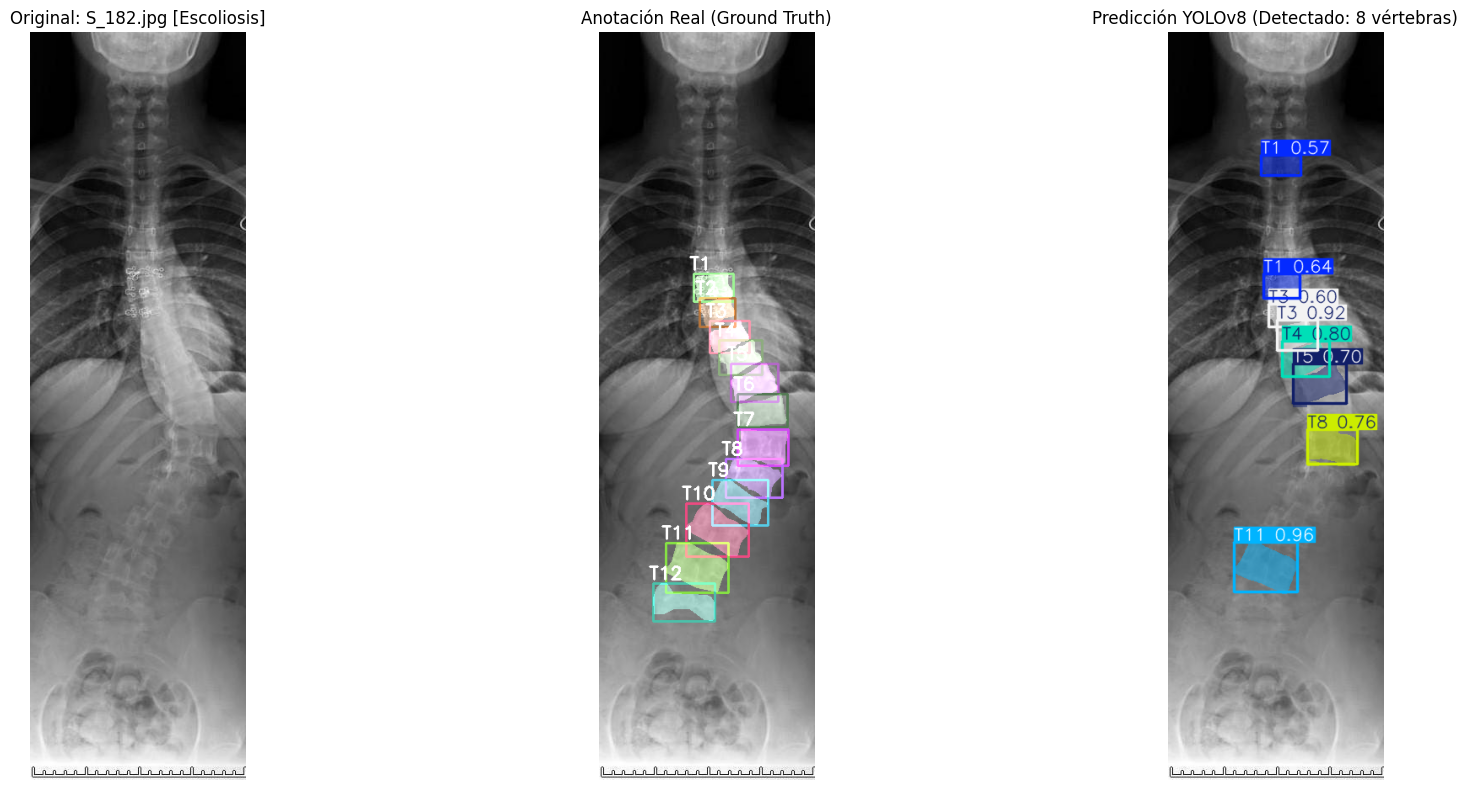

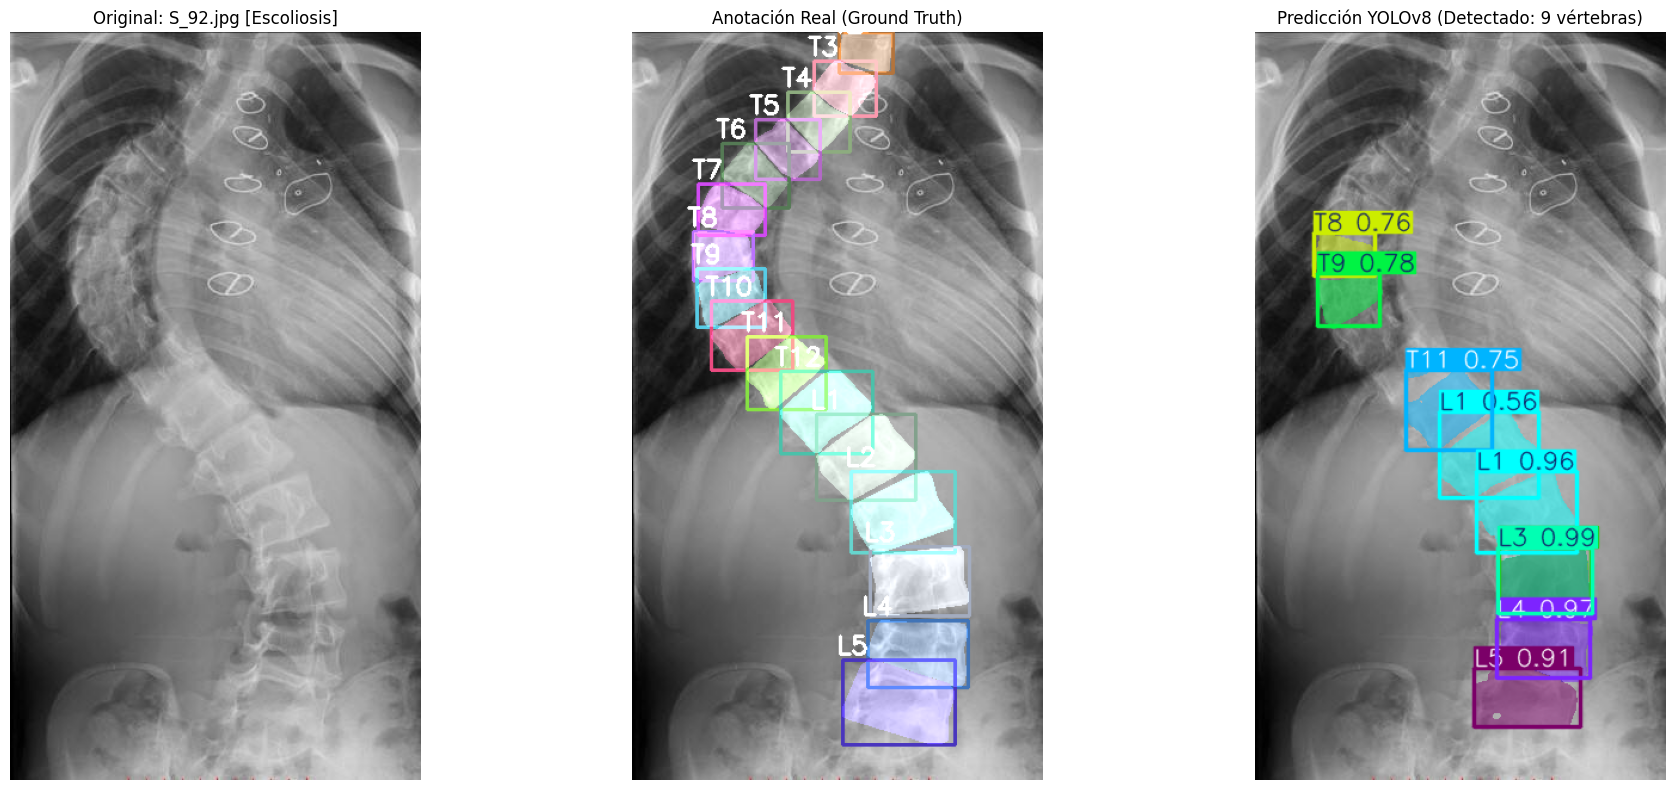

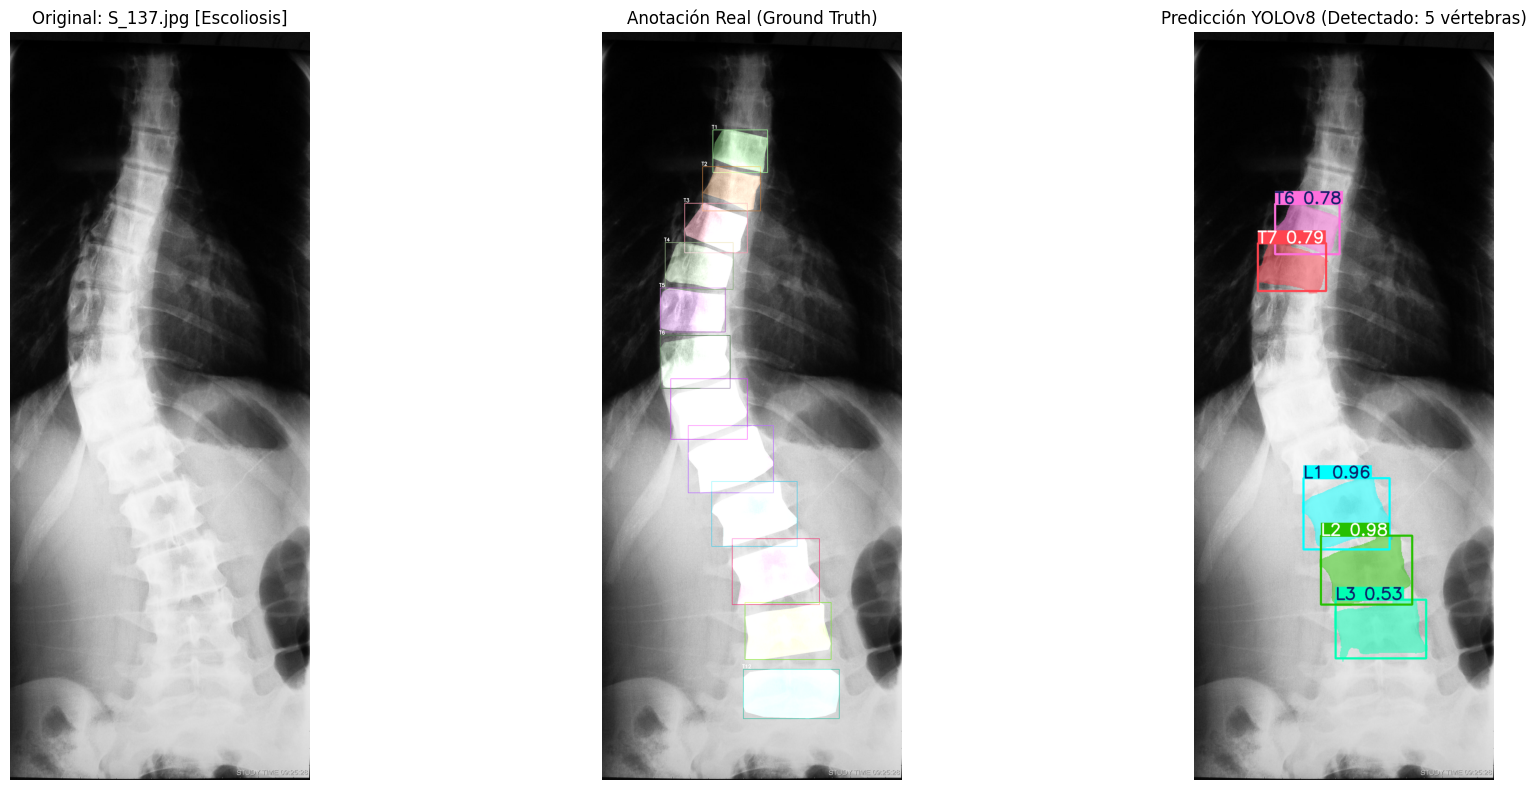

In [ ]:
%matplotlib inline
import cv2
import random
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from configs.config import ANATOMICAL_VERTEBRAE

# 1. Obtener imágenes y separar
all_test_images = list(Path('yolo_dataset/images/test').glob('*.*'))
normal_imgs = [img for img in all_test_images if img.name.startswith('N_')]
scoliosis_imgs = [img for img in all_test_images if img.name.startswith('S_')]

# Muestra equitativa
random.seed(42)
sample_imgs = random.sample(normal_imgs, min(3, len(normal_imgs))) + \
              random.sample(scoliosis_imgs, min(3, len(scoliosis_imgs)))

# Paleta de 17 colores consistentes al estilo YOLO 
random.seed(0)
colors = [(random.randint(50, 255), random.randint(50, 255), random.randint(50, 255)) for _ in range(17)]

for img_path in sample_imgs:
    img_bgr = cv2.imread(str(img_path))
    h, w = img_bgr.shape[:2]
    
    # 2. Construir GROUND TRUTH de instancias
    img_gt = img_bgr.copy()
    overlay = np.zeros_like(img_bgr) # Capa para transparencias
    
    label_path = str(img_path).replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    if Path(label_path).exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 7:
                    cls_id = int(parts[0])
                    color = colors[cls_id % len(colors)]
                    
                    # Convertir puntos
                    coords = list(map(float, parts[1:]))
                    pts = np.array([[int(coords[j]*w), int(coords[j+1]*h)] for j in range(0, len(coords), 2)])
                    
                    # Rellenar polígono y calcular Bounding Box
                    cv2.fillPoly(overlay, [pts], color)
                    x, y, bw, bh = cv2.boundingRect(pts)
                    
                    # Dibujar Caja y Texto en imagen base
                    cv2.rectangle(img_gt, (x, y), (x+bw, y+bh), color, 2)
                    name_tag = ANATOMICAL_VERTEBRAE[cls_id]
                    cv2.putText(img_gt, name_tag, (max(0, x-5), max(0, y-5)), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    
    # Unir imagen con máscara transparente
    img_gt = cv2.addWeighted(img_gt, 1.0, overlay, 0.4, 0)
    img_gt = cv2.cvtColor(img_gt, cv2.COLOR_BGR2RGB)

    # 3. Obtener PREDICCIÓN gráfica de instancias vía YOLO
    res = model_best.predict(str(img_path), conf=0.5, verbose=False)[0]
    img_pred = cv2.cvtColor(res.plot(labels=True, conf=True), cv2.COLOR_BGR2RGB)
    
    # ================= GRAFICAR ================= #
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    tipo = "Normal" if img_path.name.startswith('N_') else "Escoliosis"
    
    axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Original: {img_path.name} [{tipo}]")
    axes[0].axis('off')
    
    axes[1].imshow(img_gt)
    axes[1].set_title(f"Anotación Real (Ground Truth)")
    axes[1].axis('off')
    
    axes[2].imshow(img_pred)
    axes[2].set_title(f"Predicción YOLOv8 (Detectado: {len(res.boxes)} vértebras)")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()


## 7. Análisis focalizado: L4-L5

In [ ]:
# Análisis focalizado: L4-L5 y regiones problemáticas
from configs.config import VERTEBRA_TO_CLASS_ID

print("=" * 70)
print("ANÁLISIS FOCALIZADO")
print("=" * 70)

df_class = summary['per_class']

# L4-L5 (antecedente: Dice ≈ 0.52)
print("\n🦴 L4-L5 (antecedente Dice ≈ 0.52):")
for v in ['L4', 'L5']:
    cid = VERTEBRA_TO_CLASS_ID[v]
    row = df_class[df_class['class_id'] == cid]
    if len(row) > 0:
        r = row.iloc[0]
        status = '✅' if r['dice_mean'] > 0.52 else '⚠️'
        print(f"  {status} {v}: Dice={r['dice_mean']:.4f} ± {r['dice_std']:.4f} "
              f"IoU={r['iou_mean']:.4f} (n={r['n_images']:.0f})")

# Top-5 mejores y peores
print("\n🏆 Top-5 MEJORES vértebras:")
df_sorted = df_class[df_class['class_id'] > 0].sort_values('dice_mean', ascending=False)
for _, row in df_sorted.head(5).iterrows():
    print(f"  {row['vertebra']}: Dice={row['dice_mean']:.4f}")

print("\n⚠️ Top-5 PEORES vértebras:")
for _, row in df_sorted.tail(5).iterrows():
    print(f"  {row['vertebra']}: Dice={row['dice_mean']:.4f} (n={row['n_images']:.0f})")

# Comparación con baselines
print(f"\n📊 vs BASELINES del antecedente [16]:")
our_dice = summary['dice_vertebra_mean']
print(f"  {'Modelo':<30} {'Dice Vert':>10} {'Δ':>10}")
print(f"  {'-'*50}")
print(f"  {'** NUESTRO **':<30} {our_dice:>10.4f} {'---':>10}")
print(f"  {'YOLOv8m-seg (antecedente)':<30} {'0.7400':>10} {our_dice - 0.74:>+10.4f}")
print(f"  {'Mask R-CNN (antecedente)':<30} {'0.7700':>10} {our_dice - 0.77:>+10.4f}")
print(f"  {'U-Net binaria (antecedente)':<30} {'0.5400':>10} {our_dice - 0.54:>+10.4f}")


ANÁLISIS FOCALIZADO

🦴 L4-L5 (antecedente Dice ≈ 0.52):
  ✅ L4: Dice=0.5806 ± 0.4398 IoU=0.5350 (n=11)
  ⚠️ L5: Dice=0.3552 ± 0.4212 IoU=0.3105 (n=12)

🏆 Top-5 MEJORES vértebras:
  L4: Dice=0.5806
  T11: Dice=0.5308
  T1: Dice=0.5141
  T10: Dice=0.4746
  T2: Dice=0.4456

⚠️ Top-5 PEORES vértebras:
  T12: Dice=0.3797 (n=25)
  L2: Dice=0.3791 (n=12)
  L1: Dice=0.3741 (n=14)
  T3: Dice=0.3590 (n=25)
  L5: Dice=0.3552 (n=12)

📊 vs BASELINES del antecedente [16]:
  Modelo                          Dice Vert          Δ
  --------------------------------------------------
  ** NUESTRO **                      0.4251        ---
  YOLOv8m-seg (antecedente)          0.7400    -0.3149
  Mask R-CNN (antecedente)           0.7700    -0.3449
  U-Net binaria (antecedente)        0.5400    -0.1149


## 8. Métricas de eficiencia

In [ ]:
import time

model_path = Path(best_path)
model_size_mb = model_path.stat().st_size / 1024 / 1024
total_params = sum(p.numel() for p in model_best.model.parameters())

test_img = str(list(Path('yolo_dataset/images/test').glob('*.*'))[0])
for _ in range(5): _ = model_best.predict(test_img, verbose=False)

times = []
for _ in range(20):
    t0 = time.time()
    _ = model_best.predict(test_img, verbose=False)
    times.append((time.time() - t0) * 1000)

print("=" * 70)
print("MÉTRICAS DE EFICIENCIA - YOLOv8")
print("=" * 70)
print(f"  Parámetros: {total_params:,} ({total_params/1e6:.1f}M)")
print(f"  Tamaño: {model_size_mb:.1f} MB")
print(f"  Inferencia: {np.mean(times):.1f} ± {np.std(times):.1f} ms")
print(f"  vs Antecedente: 52 MB, ~19 ms")

MÉTRICAS DE EFICIENCIA - YOLOv8
  Parámetros: 3,261,379 (3.3M)
  Tamaño: 6.5 MB
  Inferencia: 5.3 ± 0.3 ms
  vs Antecedente: 52 MB, ~19 ms


## 9. Guardar resultados

In [ ]:
import json

results_yolo = {
    'strategy': 'YOLOv8m-seg',
    'dice_vertebra_mean': float(summary['dice_vertebra_mean']),
    'dice_vertebra_std': float(summary['dice_vertebra_std']),
    'iou_vertebra_mean': float(summary['iou_vertebra_mean']),
    'dice_spine_mean': float(summary['dice_spine_mean']),
    'model_size_mb': model_size_mb,
    'params_millions': total_params / 1e6,
    'inference_gpu_ms': float(np.mean(times)),
    'per_class': summary['per_class'].to_dict('records'),
    'per_region': summary['per_region'].to_dict('records'),
    'per_type': summary['per_type'].to_dict('records'),
    'hyperparams': {
        'model': YOLO_MODEL_SIZE, 'imgsz': IMG_SIZES['yolo_medium'],
        'freeze': YOLO_FREEZE_LAYERS, 'batch': BATCH_SIZE,
        'epochs': MAX_EPOCHS, 'conf_threshold': YOLO_CONFIDENCE_THRESHOLD
    }
}

os.makedirs(str(METRICS_DIR), exist_ok=True)
with open(str(METRICS_DIR / 'results_yolov8m_seg.json'), 'w') as f:
    json.dump(results_yolo, f, indent=2)
print(f"Guardado: {METRICS_DIR / 'results_yolov8m_seg.json'}")
print(f"\n📋 RESUMEN FINAL YOLOv8:")
print(f"  Dice: {results_yolo['dice_vertebra_mean']:.4f}")
print(f"  Modelo: {results_yolo['model_size_mb']:.1f}MB, {float(np.mean(times)):.1f}ms")

Guardado: outputs/runs/20260509_231525/metrics/results_yolov8m_seg.json

📋 RESUMEN FINAL YOLOv8:
  Dice: 0.4251
  Modelo: 6.5MB, 5.3ms


Dataset YOLO: /home/becavas/data/repos/spine_seg/notebooks/yolo_dataset
Clases declaradas: 17 | rango esperado: 0-16
Número de nombres en YAML: 17


,split,imagenes,labels_vacias,labels_faltantes,lineas_mal_formadas,lineas_fuera_rango,instancias_validas,clases_unicas
0,train,199,0,0,0,0,2727,17
1,val,25,0,0,0,0,349,17
2,test,25,0,0,0,0,343,17


No se detectaron problemas de formato ni clases fuera de rango en el muestreo completo.
Clases YOLO presentes en las etiquetas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
S_184.jpg [train]: classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], bad_lines=0, exact_match=0.9971, fg_IoU=0.9197, mean_Dice=0.9607
S_91.jpg [train]: classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], bad_lines=0, exact_match=0.9961, fg_IoU=0.9786, mean_Dice=0.9897
S_59.jpg [train]: classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], bad_lines=0, exact_match=0.9960, fg_IoU=0.9641, mean_Dice=0.9835


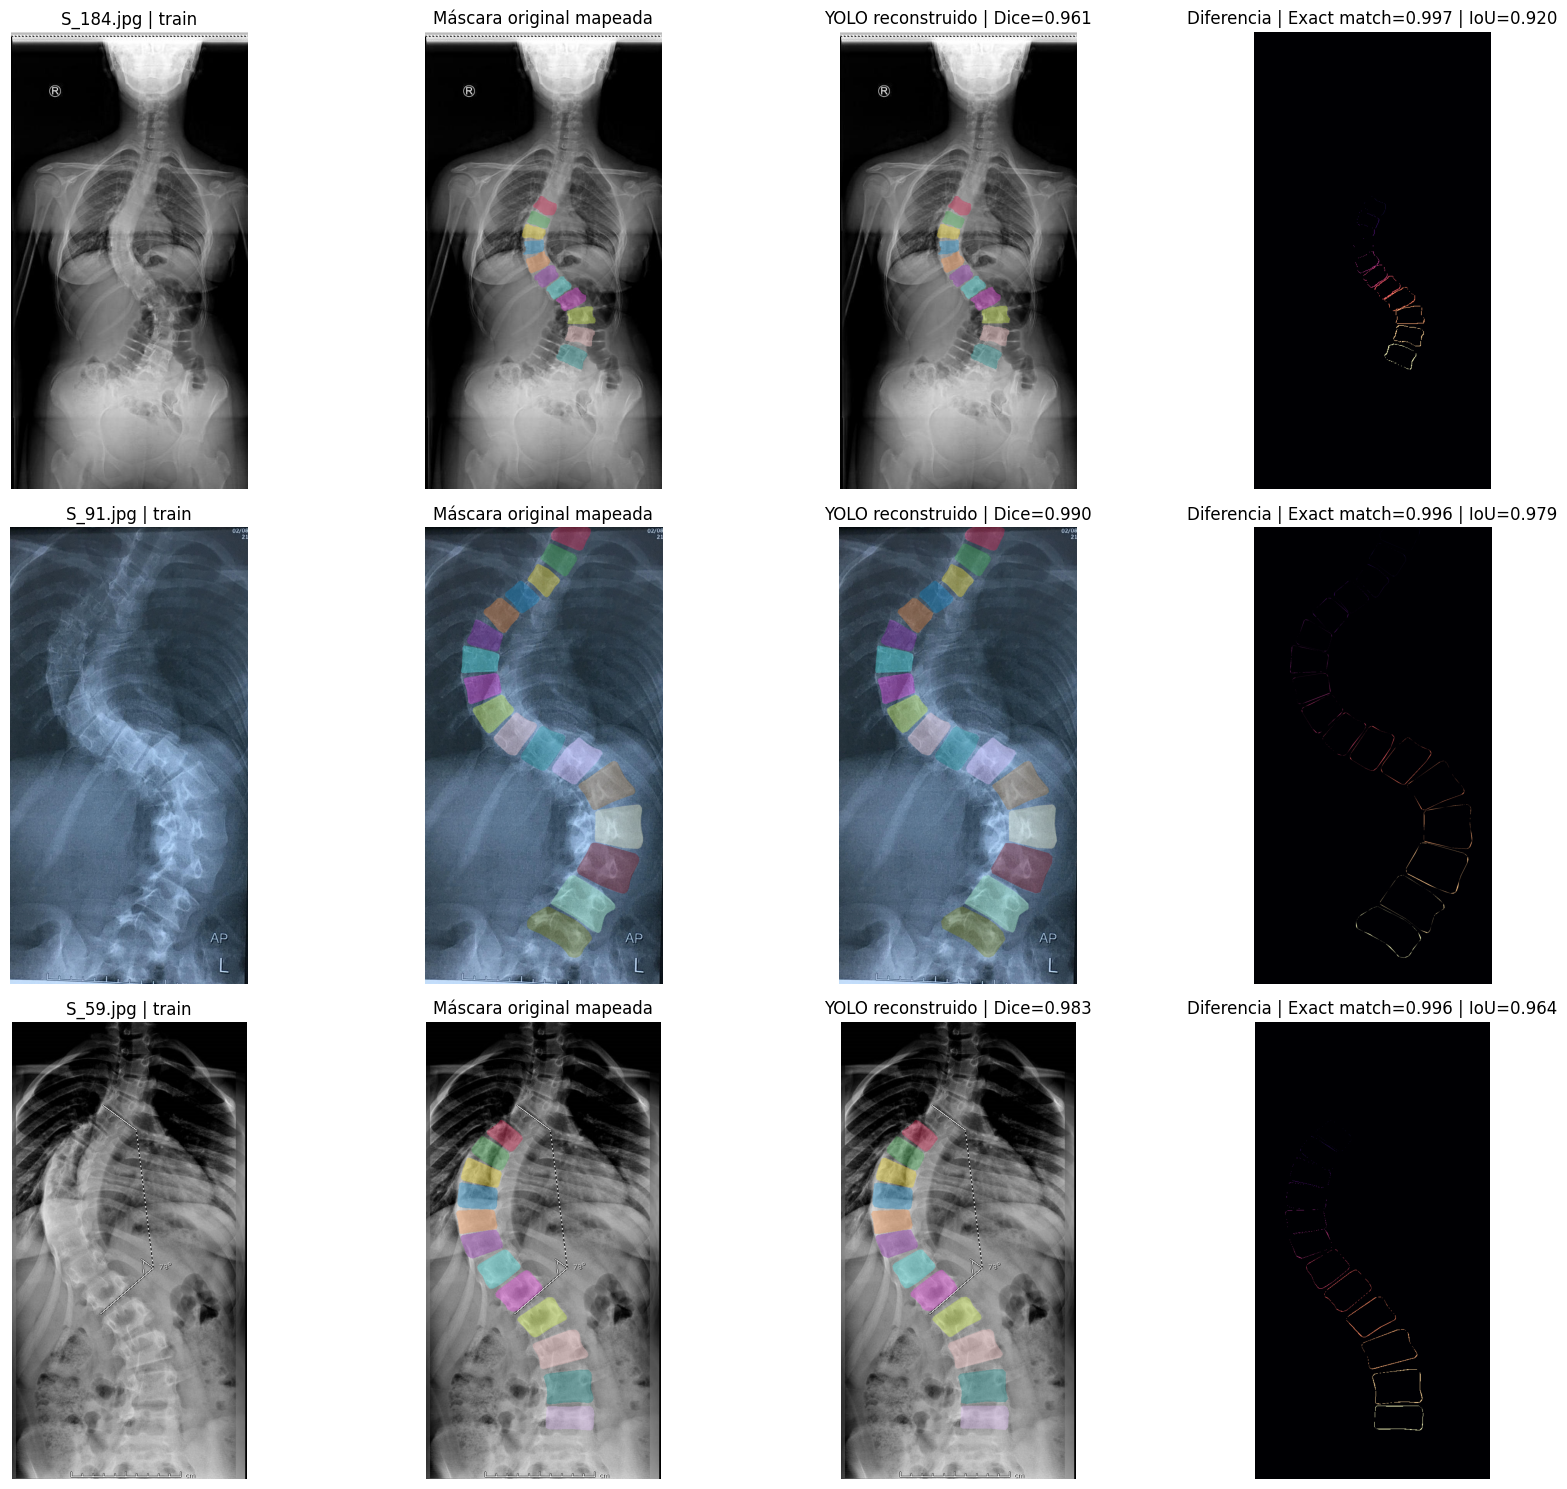

In [ ]:
import pandas as pd
# Auditoría de la conversión YOLO: integridad de labels + validación visual
from collections import Counter
import random
import yaml
from matplotlib.patches import Patch

yaml_file = Path(yaml_path)
assert yaml_file.exists(), f'No se encontró {yaml_file}'

with open(yaml_file, 'r') as f:
    yolo_cfg = yaml.safe_load(f)

dataset_root = Path(yolo_cfg['path'])
nc = int(yolo_cfg['nc'])
class_names = list(yolo_cfg['names'])
split_rows = {'train': df_train, 'val': df_val, 'test': df_test}
print(f'Dataset YOLO: {dataset_root}')
print(f'Clases declaradas: {nc} | rango esperado: 0-{nc - 1}')
print(f'Número de nombres en YAML: {len(class_names)}')

def _read_yolo_label_file(label_path):
    lines = []
    if not label_path.exists():
        return lines
    with open(label_path, 'r') as f:
        for raw in f:
            raw = raw.strip()
            if raw:
                lines.append(raw)
    return lines

def _reconstruct_mask_from_yolo(label_path, h, w):
    mask = np.zeros((h, w), dtype=np.int32)
    bad_lines = []
    class_ids = []
    for line_no, line in enumerate(_read_yolo_label_file(label_path), start=1):
        parts = line.split()
        if len(parts) < 7 or (len(parts) - 1) % 2 != 0:
            bad_lines.append((line_no, 'formato inválido'))
            continue
        try:
            cls_id = int(parts[0])
            coords = np.array(list(map(float, parts[1:])), dtype=np.float32)
        except ValueError:
            bad_lines.append((line_no, 'no numérico'))
            continue
        if cls_id < 0 or cls_id >= nc:
            bad_lines.append((line_no, f'clase fuera de rango: {cls_id}'))
            continue
        if np.any(coords < -1e-6) or np.any(coords > 1 + 1e-6):
            bad_lines.append((line_no, 'coordenadas fuera de [0,1]'))
            continue
        pts = []
        for x, y in coords.reshape(-1, 2):
            px = int(np.clip(round(x * (w - 1)), 0, w - 1))
            py = int(np.clip(round(y * (h - 1)), 0, h - 1))
            pts.append([px, py])
        pts = np.asarray(pts, dtype=np.int32)
        if len(pts) < 3:
            bad_lines.append((line_no, 'polígono degenerado'))
            continue
        cv2.fillPoly(mask, [pts], cls_id + 1)
        class_ids.append(cls_id)
    return mask, class_ids, bad_lines

def _reconstruct_semantic_mask_from_original(mask_path):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
    if mask is None:
        return None
    if mask.ndim == 3:
        mask = mask[..., 0]
    mask = mask.astype(np.int32)
    semantic = np.zeros_like(mask, dtype=np.int32)
    for orig_id, model_class_id in label_mapping.items():
        semantic[mask == int(orig_id)] = int(model_class_id)
    return semantic

def _dice_score(a, b, cls_id):
    a_bin = (a == cls_id)
    b_bin = (b == cls_id)
    denom = a_bin.sum() + b_bin.sum()
    return 1.0 if denom == 0 else float((2.0 * np.logical_and(a_bin, b_bin).sum()) / denom)

def _foreground_iou(a, b):
    a_bin = a > 0
    b_bin = b > 0
    union = np.logical_or(a_bin, b_bin).sum()
    return 1.0 if union == 0 else float(np.logical_and(a_bin, b_bin).sum() / union)

rows = []
bad_examples = []
all_class_ids = Counter()
for split_name, df_split in split_rows.items():
    img_dir = dataset_root / 'images' / split_name
    label_dir = dataset_root / 'labels' / split_name
    image_files = sorted(img_dir.glob('*.*'))
    missing_labels = 0
    empty_labels = 0
    malformed_lines = 0
    out_of_range_lines = 0
    split_instances = 0
    split_class_ids = Counter()
    for img_path in image_files:
        label_path = label_dir / f'{img_path.stem}.txt'
        if not label_path.exists():
            missing_labels += 1
            continue
        lines = _read_yolo_label_file(label_path)
        if not lines:
            empty_labels += 1
            continue
        for line_no, line in enumerate(lines, start=1):
            parts = line.split()
            if len(parts) < 7 or (len(parts) - 1) % 2 != 0:
                malformed_lines += 1
                if len(bad_examples) < 12:
                    bad_examples.append({'split': split_name, 'image': img_path.name, 'line': line_no, 'issue': 'formato inválido', 'raw': line[:140]})
                continue
            try:
                cls_id = int(parts[0])
                coords = np.array(list(map(float, parts[1:])), dtype=np.float32)
            except ValueError:
                malformed_lines += 1
                if len(bad_examples) < 12:
                    bad_examples.append({'split': split_name, 'image': img_path.name, 'line': line_no, 'issue': 'no numérico', 'raw': line[:140]})
                continue
            if cls_id < 0 or cls_id >= nc:
                out_of_range_lines += 1
                if len(bad_examples) < 12:
                    bad_examples.append({'split': split_name, 'image': img_path.name, 'line': line_no, 'issue': f'clase fuera de rango ({cls_id})', 'raw': line[:140]})
                continue
            if np.any(coords < -1e-6) or np.any(coords > 1 + 1e-6):
                malformed_lines += 1
                if len(bad_examples) < 12:
                    bad_examples.append({'split': split_name, 'image': img_path.name, 'line': line_no, 'issue': 'coordenadas fuera de [0,1]', 'raw': line[:140]})
                continue
            split_instances += 1
            split_class_ids[cls_id] += 1
            all_class_ids[cls_id] += 1
    rows.append({
        'split': split_name,
        'imagenes': len(image_files),
        'labels_vacias': empty_labels,
        'labels_faltantes': missing_labels,
        'lineas_mal_formadas': malformed_lines,
        'lineas_fuera_rango': out_of_range_lines,
        'instancias_validas': split_instances,
        'clases_unicas': len(split_class_ids),
    })

validation_df = pd.DataFrame(rows)
display(validation_df)

if bad_examples:
    print('Ejemplos de problemas detectados en labels:')
    display(pd.DataFrame(bad_examples))
else:
    print('No se detectaron problemas de formato ni clases fuera de rango en el muestreo completo.')

print('Clases YOLO presentes en las etiquetas:', sorted(all_class_ids.keys()))
if any((cls_id < 0 or cls_id >= nc) for cls_id in all_class_ids.keys()):
    print('⚠️ Hay clases fuera de rango. La conversión debe corregirse antes de entrenar.')

sample_df = pd.concat([
    df_train.assign(_yolo_split='train'),
    df_val.assign(_yolo_split='val'),
    df_test.assign(_yolo_split='test'),
], ignore_index=True)
sample_df = sample_df.sample(n=min(3, len(sample_df)), random_state=RANDOM_SEED).reset_index(drop=True)

def _make_overlay(image_rgb, mask, alpha=0.35):
    base = image_rgb.copy().astype(np.float32)
    palette = np.array([
        [0, 0, 0], [230, 25, 75], [60, 180, 75], [255, 225, 25], [0, 130, 200],
        [245, 130, 48], [145, 30, 180], [70, 240, 240], [240, 50, 230], [210, 245, 60],
        [250, 190, 190], [0, 128, 128], [230, 190, 255], [170, 110, 40], [255, 250, 200],
        [128, 0, 0], [170, 255, 195], [128, 128, 0], [255, 215, 180], [0, 0, 128],
    ], dtype=np.float32)
    overlay = base.copy()
    for cls_id in np.unique(mask):
        if cls_id == 0:
            continue
        color = palette[int(cls_id) % len(palette)]
        overlay[mask == cls_id] = color
    return np.clip((1 - alpha) * base + alpha * overlay, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(len(sample_df), 4, figsize=(18, 5 * len(sample_df)))
if len(sample_df) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, row in sample_df.iterrows():
    yolo_split = row['_yolo_split']
    img_path = Path(DATASET_ROOT) / row['radiograph_path']
    orig_mask_path = Path(DATASET_ROOT) / row['multiclass_id_png']
    img_stem = Path(row['image']).stem
    yolo_label_path = dataset_root / 'labels' / yolo_split / f'{img_stem}.txt'
    img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    orig_sem = _reconstruct_semantic_mask_from_original(orig_mask_path)
    if orig_sem is None:
        continue
    yolo_sem, yolo_classes, bad_lines = _reconstruct_mask_from_yolo(yolo_label_path, h, w)
    fg_iou = _foreground_iou(orig_sem, yolo_sem)
    dice_vals = [_dice_score(orig_sem, yolo_sem, cls_id) for cls_id in np.unique(orig_sem) if cls_id > 0]
    mean_dice = float(np.mean(dice_vals)) if dice_vals else 1.0
    exact_match = float((orig_sem == yolo_sem).mean())

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"{row['image']} | {yolo_split}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(_make_overlay(img, orig_sem))
    axes[i, 1].set_title('Máscara original mapeada')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(_make_overlay(img, yolo_sem))
    axes[i, 2].set_title(f'YOLO reconstruido | Dice={mean_dice:.3f}')
    axes[i, 2].axis('off')

    diff = np.abs(orig_sem - yolo_sem)
    axes[i, 3].imshow(diff, cmap='magma')
    axes[i, 3].set_title(f'Diferencia | Exact match={exact_match:.3f} | IoU={fg_iou:.3f}')
    axes[i, 3].axis('off')

    print(f"{row['image']} [{yolo_split}]: classes={sorted(set(yolo_classes))}, bad_lines={len(bad_lines)}, exact_match={exact_match:.4f}, fg_IoU={fg_iou:.4f}, mean_Dice={mean_dice:.4f}")

plt.tight_layout()
plt.show()